In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import pandas as pd

In [2]:
import pandas as pd

# Load metadata of UrbanSound8K dataset
metadata_path = '/Users/SHUNMU/Downloads/mini1/UrbanSound8k.csv'  # Update with the correct path
urban_df = pd.read_csv(metadata_path)

# Preview the dataset
print(urban_df.head())

      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


In [3]:
# Function to extract features
def extract_features(file_name):
    try:
        # Load the audio file with librosa
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_scaled = np.mean(mfccs.T, axis=0)
    except Exception as e:
        # Log the error and continue
        print(f"Error encountered while parsing file: {file_name}")
        print(str(e))
        return None 
    return mfccs_scaled

In [ ]:
# Function to prepare the dataset
def prepare_dataset(urban_sound_data, audio_dir):
    features = []
    for index, row in urban_sound_data.iterrows():
        file_name = os.path.join(audio_dir, f"fold{row['fold']}", row['slice_file_name'])
        class_label = row["classID"]
        
        # Extract features for each file
        data = extract_features(file_name)
        
        # Skip files that failed to load                                    
        if data is not None:
            features.append([data, class_label])
    
    return features

In [20]:
import pandas as pd
import librosa
import os
import numpy as np

# Load the CSV file containing the metadata
file_path = r"C:\Users\SHUNMU\Downloads\mini1\UrbanSound8K.csv"
urban_sound_data = pd.read_csv(file_path)

# Function to extract features
def extract_features(file_name):
    if not os.path.exists(file_name):
        # Log the missing file and return None
        print(f"File does not exist: {file_name}")
        return None
    
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')

        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40, n_fft=512)

        # Take the mean of the MFCC features
        mfccs_scaled = np.mean(mfccs.T, axis=0)
    except Exception as e:
        # Log the error and continue
        print(f"Error encountered while parsing file: {file_name}")
        print(str(e))
        return None 
    
    return mfccs_scaled

# Function to prepare the dataset
def prepare_dataset(urban_sound_data, audio_dir):
    features = []
    missing_files = 0
    for index, row in urban_sound_data.iterrows():
        # Construct the full path to the audio file
        file_name = os.path.join(audio_dir, f"fold{row['fold']}", row['slice_file_name'])
        
        # Print file path for debugging purposes
        print(f"Attempting to load file: {file_name}")

        class_label = row["classID"]
        
        # Extract features for each file
        data = extract_features(file_name)
        
        # Skip files that failed to load and log missing file
        if data is None:
            missing_files += 1
            continue
        
        features.append([data, class_label])

    print(f"Number of missing or corrupted files: {missing_files}")
    return features

# Path to the audio directory
audio_dir = r'C:\Users\SHUNMU\Downloads\mini1\UrbanSound'

# Prepare the dataset
features = prepare_dataset(urban_sound_data, audio_dir)

# Convert the features into a DataFrame for easier handling later
features_df = pd.DataFrame(features, columns=['feature', 'class_label'])

# Print a summary
print(f"Extracted features from {len(features_df)} files")


Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100032-3-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-117.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-121.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-126.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-137.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-143.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-161.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-3.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-36.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\100648-1-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\1

In [30]:
import os
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load the CSV metadata
file_path = r"C:/Users/SHUNMU/Downloads/mini1/UrbanSound8K.csv"
urban_sound_data = pd.read_csv(file_path)

# Function to extract MFCC features
def extract_mfcc(file_name):
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        # Take the mean of the MFCC features
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        print(f"Error parsing file {file_name}: {str(e)}")
        return None

# Function to prepare the dataset
def prepare_dataset(data, audio_dir):
    features, labels = [], []
    missing_files = 0

    for i, row in data.iterrows():
        # Construct the full file path
        file_path = os.path.join(audio_dir, f"fold{row['fold']}", row['slice_file_name'])
        file_path = file_path.replace("\\", "/")  # Ensure cross-platform compatibility

        # Print the constructed file path for debugging
        print(f"Attempting to load file: {file_path}")

        # Check if the file exists
        if os.path.exists(file_path):
            mfccs = extract_mfcc(file_path)
            if mfccs is not None:
                features.append(mfccs)
                labels.append(row['classID'])
        else:
            missing_files += 1
            print(f"File not found: {file_path}")  # Print missing file details

    print(f"Total missing files: {missing_files}")
    return np.array(features), np.array(labels)

# Set the path to the UrbanSound8K dataset
audio_dir = r'C:/Users/SHUNMU/Downloads/mini1/UrbanSound'

# Prepare the dataset
X, y = prepare_dataset(urban_sound_data, audio_dir)

# Check if any data was loaded
if X.size == 0 or y.size == 0:
    print("No data was loaded. Please check the file paths and dataset.")
else:
    # One-hot encode the labels (classID)
    y = to_categorical(y)

    # Split into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Reshape for 1D CNN
    X_train_cnn1d = np.expand_dims(X_train, axis=2)
    X_test_cnn1d = np.expand_dims(X_test, axis=2)

    # Reshape for 2D CNN
    X_train_cnn2d = np.expand_dims(X_train, axis=(1, 2))
    X_test_cnn2d = np.expand_dims(X_test, axis=(1, 2))

    # Print dataset shapes
    print(f"Shape of X_train_cnn1d: {X_train_cnn1d.shape}")
    print(f"Shape of X_train_cnn2d: {X_train_cnn2d.shape}")
    print(f"Shape of X_test_cnn1d: {X_test_cnn1d.shape}")
    print(f"Shape of X_test_cnn2d: {X_test_cnn2d.shape}")


Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100032-3-0-0.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-117.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-121.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-126.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-137.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-143.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-161.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-3.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/100263-2-0-36.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold10/100648-1-0-0.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold10/1

c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(


Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold7/173891-9-0-11.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold7/173891-9-0-17.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold7/173891-9-0-2.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold7/173891-9-0-7.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/173993-3-0-25.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/173993-3-0-39.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/173993-3-0-51.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold5/173993-3-0-52.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold4/173994-3-0-14.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold4/173994-3-0-3.wav
Attempting to load file: C:/Users/SHUNMU/Downloads/mini1/UrbanSound/fold4/173994-3-

1d cnn

Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100032-3-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-117.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-121.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-126.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-137.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-143.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-161.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-3.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-36.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\100648-1-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\1

c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.2467 - loss: 2.5205 - val_accuracy: 0.4485 - val_loss: 1.5583 - learning_rate: 0.0010
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.3951 - loss: 1.6986 - val_accuracy: 0.5528 - val_loss: 1.2805 - learning_rate: 0.0010
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.4542 - loss: 1.5179 - val_accuracy: 0.5980 - val_loss: 1.1472 - learning_rate: 0.0010
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.5205 - loss: 1.4004 - val_accuracy: 0.6743 - val_loss: 1.0139 - learning_rate: 0.0010
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.5428 - loss: 1.3070 - val_accuracy: 0.6889 - val_loss: 0.9588 - learning_rate: 0.0010
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.5863 - loss: 1.2078 - val_accuracy: 0.7125 - val_loss: 0.9091 - learning_rate: 0.0010
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.6126 - los

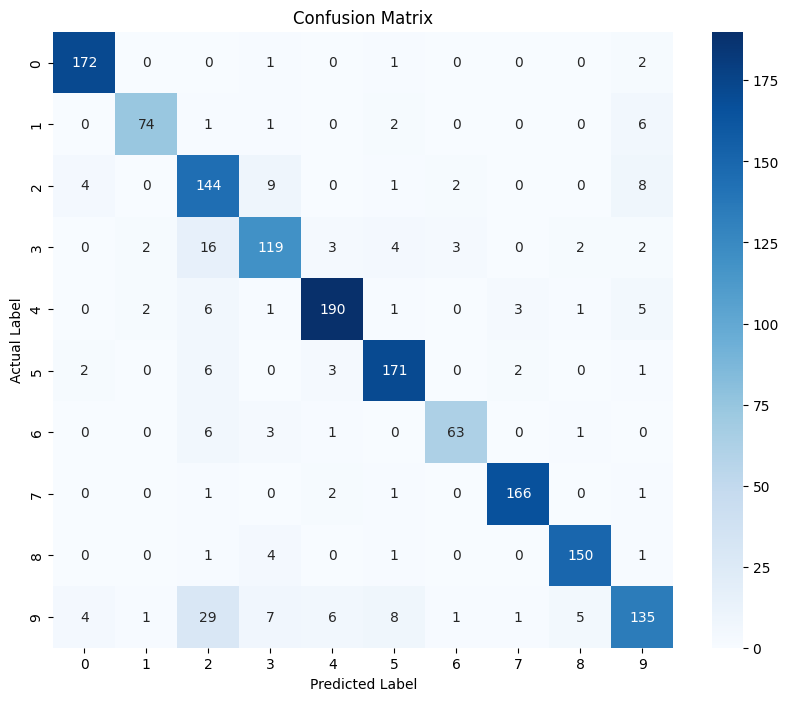

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       176
           1       0.94      0.88      0.91        84
           2       0.69      0.86      0.76       168
           3       0.82      0.79      0.80       151
           4       0.93      0.91      0.92       209
           5       0.90      0.92      0.91       185
           6       0.91      0.85      0.88        74
           7       0.97      0.97      0.97       171
           8       0.94      0.96      0.95       157
           9       0.84      0.69      0.75       197

    accuracy                           0.88      1572
   macro avg       0.89      0.88      0.88      1572
weighted avg       0.88      0.88      0.88      1572



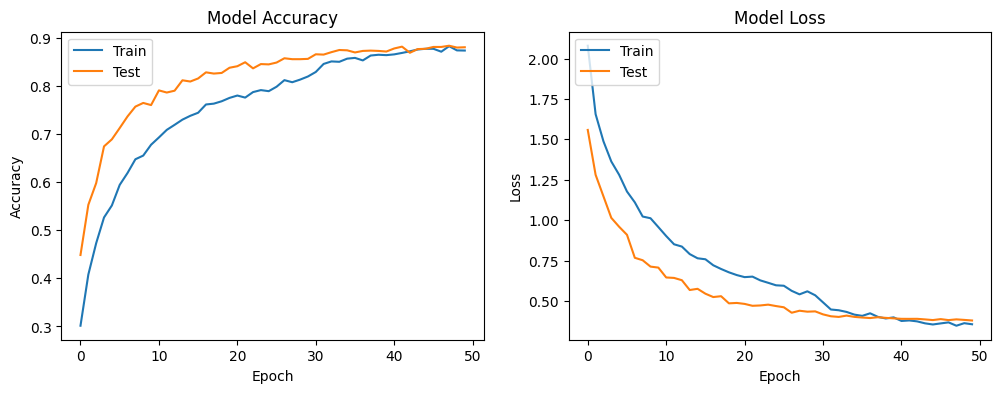

In [4]:
import pandas as pd
import librosa
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file containing the metadata
file_path = r"C:\Users\SHUNMU\Downloads\mini1\UrbanSound8K.csv"
urban_sound_data = pd.read_csv(file_path)

# Function to extract features
def extract_features(file_name):
    if not os.path.exists(file_name):
        print(f"File does not exist: {file_name}")
        return None
    
    try:
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40, n_fft=512)
        mfccs_scaled = np.mean(mfccs.T, axis=0)
    except Exception as e:
        print(f"Error encountered while parsing file: {file_name}")
        print(str(e))
        return None 
    
    return mfccs_scaled

# Function to prepare the dataset
def prepare_dataset(urban_sound_data, audio_dir):
    features = []
    for index, row in urban_sound_data.iterrows():
        file_name = os.path.join(audio_dir, f"fold{row['fold']}", row['slice_file_name'])
        print(f"Attempting to load file: {file_name}")
        class_label = row["classID"]
        data = extract_features(file_name)
        if data is None:
            continue
        features.append([data, class_label])
    
    return features

# Path to the audio directory
audio_dir = r'C:\Users\SHUNMU\Downloads\mini1\UrbanSound'
features = prepare_dataset(urban_sound_data, audio_dir)

# Convert the features into a DataFrame for easier handling later
features_df = pd.DataFrame(features, columns=['feature', 'class_label'])

# Convert features and labels into numpy arrays
X = np.array(features_df['feature'].tolist())
y = np.array(features_df['class_label'].tolist())

# Reshape X to be (samples, time_steps, channels) for 1D CNN
X = X.reshape(X.shape[0], X.shape[1], 1)

# Convert labels to categorical
y = to_categorical(y, num_classes=10)  # Assuming there are 10 classes

# Split the dataset into training and testing sets
X_train_cnn1d, X_test_cnn1d, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model building function for 1D CNN
def build_1d_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(128, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))

    model.add(Conv1D(256, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))

    model.add(Conv1D(512, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    
    model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

# Input shape for the model
input_shape_1d = (X_train_cnn1d.shape[1], 1)

# Build the 1D CNN model
model_1d_cnn = build_1d_cnn(input_shape_1d)

# Callbacks: Early Stopping and Learning Rate Reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

# Train the model
history = model_1d_cnn.fit(X_train_cnn1d, y_train, validation_data=(X_test_cnn1d, y_test),
                           epochs=50, batch_size=32, callbacks=[early_stopping, reduce_lr])

# Evaluate the model on the test data
y_pred = model_1d_cnn.predict(X_test_cnn1d)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report: Precision, Recall, F1-Score
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()


2D CNN

Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100032-3-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-117.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-121.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-126.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-137.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-143.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-161.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-3.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-36.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\100648-1-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\1

c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 42, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 38, 42, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 19, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 19, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.2404 - loss: 2.5725 - val_accuracy: 0.0496 - val_loss: 11.4323 - learning_rate: 0.0010
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.4230 - loss: 1.6071 - val_accuracy: 0.1463 - val_loss: 13.0223 - learning_rate: 0.0010
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.5021 - loss: 1.4213 - val_accuracy: 0.3441 - val_loss: 3.9182 - learning_rate: 0.0010
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.5408 - loss: 1.2918 - val_accuracy: 0.5102 - val_loss: 1.7876 - learning_rate: 0.0010
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.5809 - loss: 1.1816 - val_accuracy: 0.5515 - val_loss: 1.4493 - learning_rate: 0.0010
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.6282 - loss: 1.0427 - val_accuracy: 0.6247 - val_loss: 1.2512 - learning_rate: 0.0010
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0

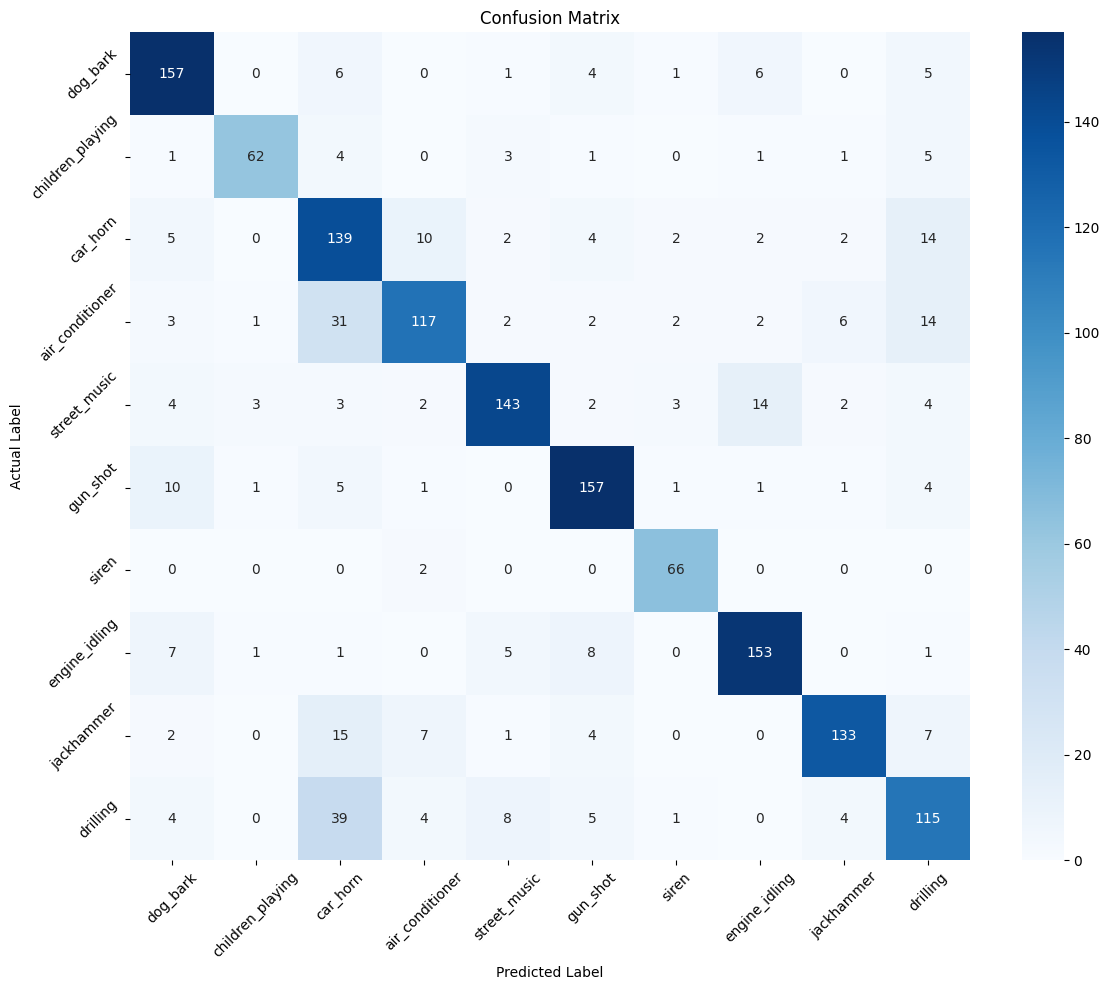

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       180
           1       0.91      0.79      0.85        78
           2       0.57      0.77      0.66       180
           3       0.82      0.65      0.72       180
           4       0.87      0.79      0.83       180
           5       0.84      0.87      0.85       181
           6       0.87      0.97      0.92        68
           7       0.85      0.87      0.86       176
           8       0.89      0.79      0.84       169
           9       0.68      0.64      0.66       180

    accuracy                           0.79      1572
   macro avg       0.81      0.80      0.80      1572
weighted avg       0.80      0.79      0.79      1572



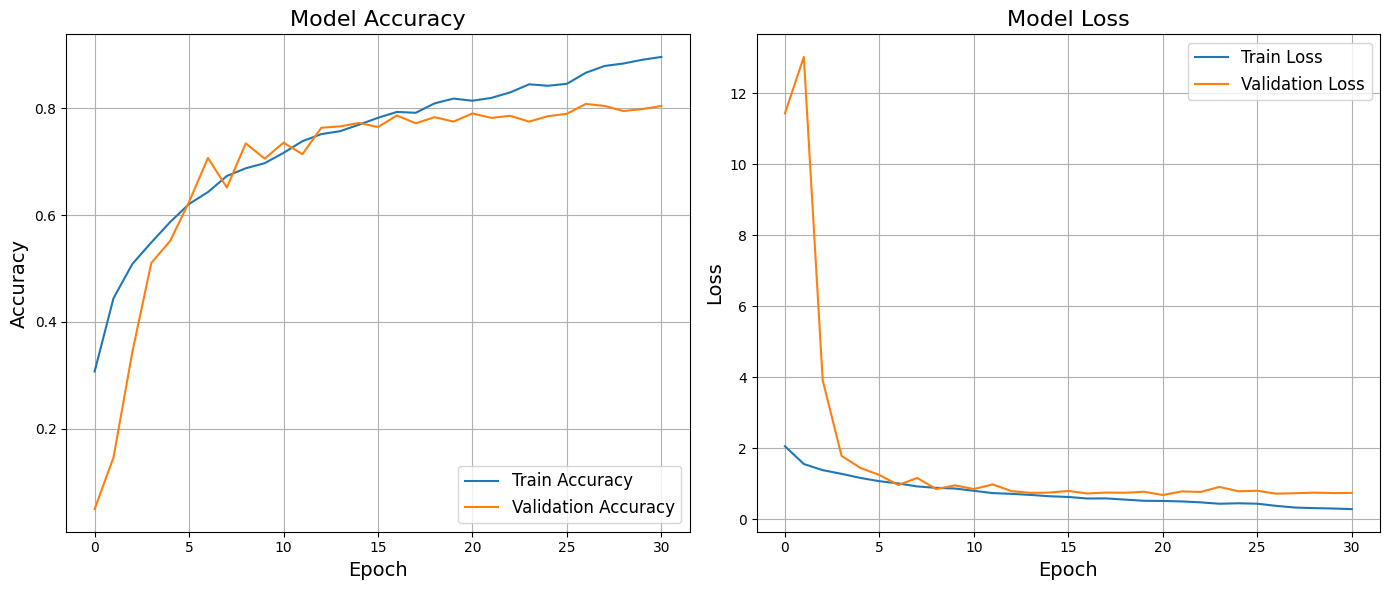

In [10]:
import pandas as pd
import librosa
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV file containing the metadata
file_path = r"C:\Users\SHUNMU\Downloads\mini1\UrbanSound8K.csv"
urban_sound_data = pd.read_csv(file_path)

# 2. Function to extract MFCC features without averaging
def extract_features(file_name, max_pad_len=44):
    if not os.path.exists(file_name):
        print(f"File does not exist: {file_name}")
        return None
    
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40, n_fft=512)
        
        # Pad or truncate to ensure consistent shape (40, max_pad_len)
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        
        return mfccs
    except Exception as e:
        print(f"Error encountered while parsing file: {file_name}")
        print(str(e))
        return None 

# 3. Function to prepare the dataset
def prepare_dataset(urban_sound_data, audio_dir, max_pad_len=44):
    features = []
    labels = []
    missing_files = 0
    
    for index, row in urban_sound_data.iterrows():
        # Construct the full path to the audio file
        file_name = os.path.join(audio_dir, f"fold{row['fold']}", row['slice_file_name'])
        
        # Print file path for debugging purposes
        print(f"Attempting to load file: {file_name}")
        
        # Extract features for each file
        data = extract_features(file_name, max_pad_len=max_pad_len)
        
        if data is None:
            missing_files += 1
            continue
        
        features.append(data)
        labels.append(row["classID"])
    
    print(f"Number of missing or corrupted files: {missing_files}")
    return np.array(features), np.array(labels)

# 4. Path to the audio directory
audio_dir = r'C:\Users\SHUNMU\Downloads\mini1\UrbanSound'

# 5. Prepare the dataset
X, y = prepare_dataset(urban_sound_data, audio_dir, max_pad_len=44)

# 6. Check the shape of the MFCC features
print(f"Shape of X before reshaping: {X.shape}")  # Expected: (num_samples, 40, 44)
print(f"Shape of y before encoding: {y.shape}")  # Expected: (num_samples,)

# 7. Normalize the MFCC features
# It's common to normalize per sample
X = X.astype('float32')
X /= np.max(np.abs(X), axis=2, keepdims=True)  # Normalize MFCCs

# 8. Convert labels to categorical
num_classes = len(np.unique(y))
y = to_categorical(y, num_classes=num_classes)

# 9. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")  # (samples, 40, 44)
print(f"Shape of X_test: {X_test.shape}")    # (samples, 40, 44)

# 10. Reshape X for 2D CNN (samples, height, width, channels)
X_train_cnn2d = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test_cnn2d = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

print(f"Shape of X_train_cnn2d: {X_train_cnn2d.shape}")  # (samples, 40, 44, 1)
print(f"Shape of X_test_cnn2d: {X_test_cnn2d.shape}")    # (samples, 40, 44, 1)

# 11. Model building function for 2D CNN
def build_2d_cnn(input_shape, num_classes):
    model = Sequential()
    
    # 1st Convolutional layer
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))
    
    # 2nd Convolutional layer
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))
    
    # 3rd Convolutional layer
    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))
    
    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    
    model.add(Dense(num_classes, activation='softmax'))  # Output layer
    
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

# 12. Build the 2D CNN model
input_shape_2d = (X_train_cnn2d.shape[1], X_train_cnn2d.shape[2], X_train_cnn2d.shape[3])  # (40, 44, 1)
model_2d_cnn = build_2d_cnn(input_shape_2d, num_classes)

# 13. Model Summary
model_2d_cnn.summary()

# 14. Callbacks: Early Stopping and Reduce Learning Rate
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 15. Train the model
history = model_2d_cnn.fit(
    X_train_cnn2d, y_train,
    validation_data=(X_test_cnn2d, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 16. Evaluate the model on the test data
y_pred = model_2d_cnn.predict(X_test_cnn2d)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 17. Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# 18. Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=urban_sound_data['class'].unique(), 
            yticklabels=urban_sound_data['class'].unique())
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# 19. Classification Report: Precision, Recall, F1-Score
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))

# 20. Plot training & validation accuracy and loss
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=16)
plt.ylabel('Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()


lstm

Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100032-3-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-117.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-121.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-126.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-137.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-143.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-161.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-3.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold5\100263-2-0-36.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\100648-1-0-0.wav
Attempting to load file: C:\Users\SHUNMU\Downloads\mini1\UrbanSound\fold10\1

c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 128)        │        88,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,986 (933.54 KB)

 Trainable params: 238,474 (931.54 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.1337 - loss: 2.7852 - val_accuracy: 0.2061 - val_loss: 2.1457 - learning_rate: 0.0010
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.2419 - loss: 2.1193 - val_accuracy: 0.3403 - val_loss: 1.7682 - learning_rate: 0.0010
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.3182 - loss: 1.8446 - val_accuracy: 0.2405 - val_loss: 1.9831 - learning_rate: 0.0010
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.3862 - loss: 1.6343 - val_accuracy: 0.3403 - val_loss: 1.8245 - learning_rate: 0.0010
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.4180 - loss: 1.5347 - val_accuracy: 0.4427 - val_loss: 1.5089 - learning_rate: 0.0010
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.5112 - loss: 1.3569 - val_accuracy: 0.4307 - val_loss: 1.6004 - learning_rate: 0.0010
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.5

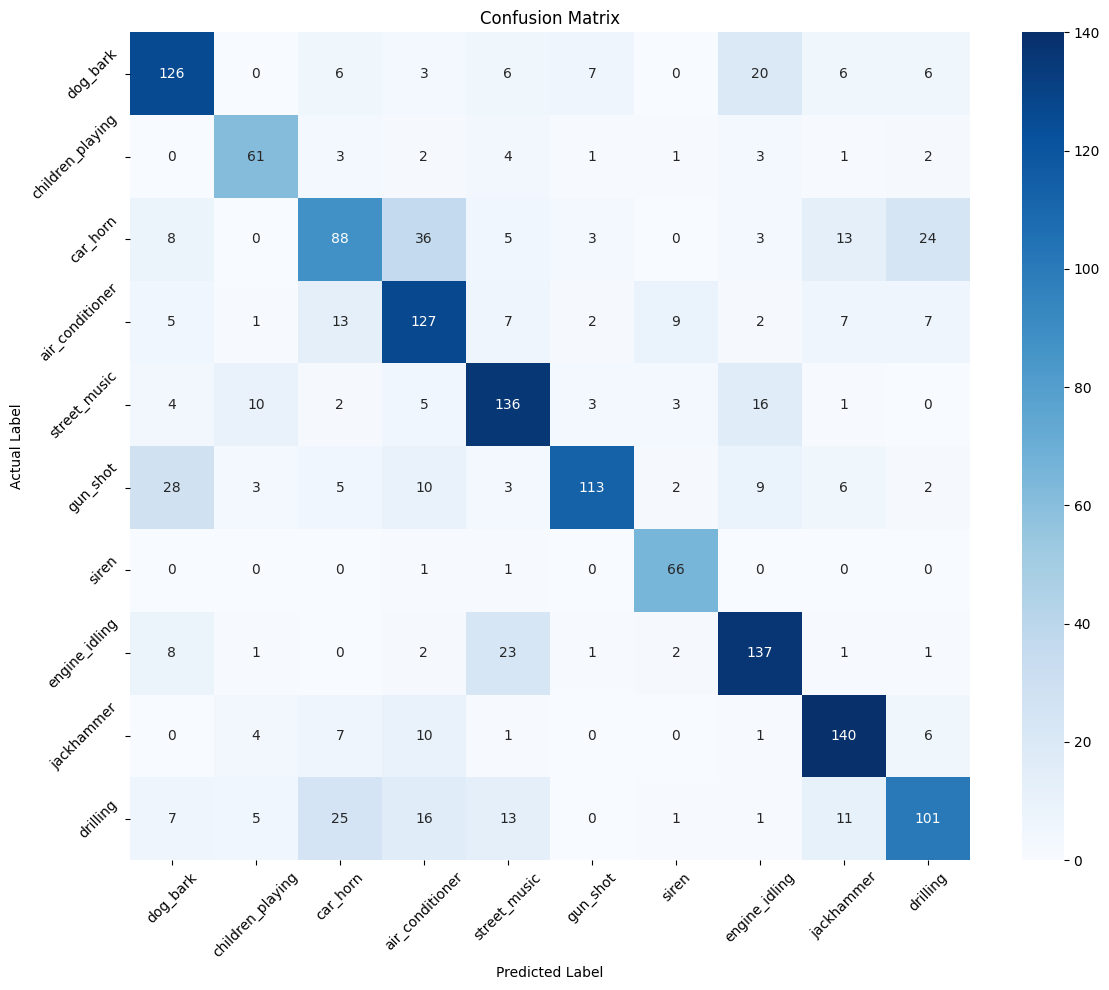

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.70      0.69       180
           1       0.72      0.78      0.75        78
           2       0.59      0.49      0.53       180
           3       0.60      0.71      0.65       180
           4       0.68      0.76      0.72       180
           5       0.87      0.62      0.73       181
           6       0.79      0.97      0.87        68
           7       0.71      0.78      0.74       176
           8       0.75      0.83      0.79       169
           9       0.68      0.56      0.61       180

    accuracy                           0.70      1572
   macro avg       0.71      0.72      0.71      1572
weighted avg       0.70      0.70      0.69      1572



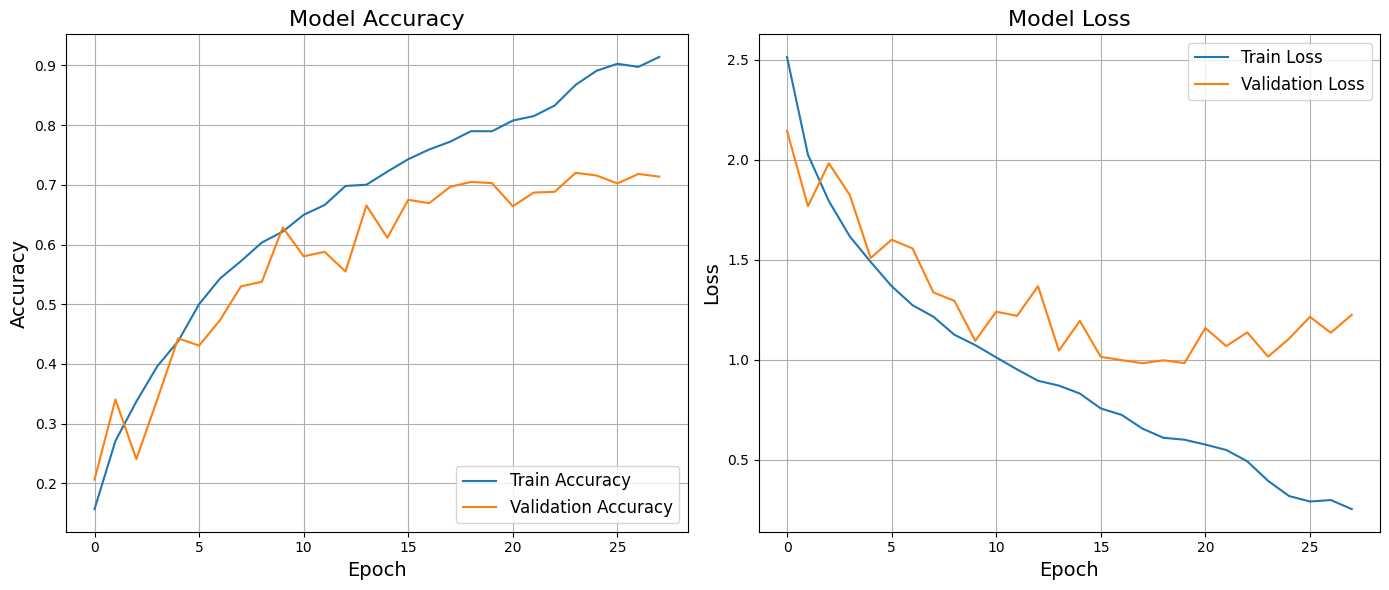

In [11]:
import pandas as pd
import librosa
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV file containing the metadata
file_path = r"C:\Users\SHUNMU\Downloads\mini1\UrbanSound8K.csv"
urban_sound_data = pd.read_csv(file_path)

# 2. Function to extract MFCC features for LSTM without averaging
def extract_features(file_name, max_pad_len=44):
    if not os.path.exists(file_name):
        print(f"File does not exist: {file_name}")
        return None
    
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        
        # Extract MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40, n_fft=512)
        
        # Pad or truncate to ensure consistent shape (40, max_pad_len)
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        
        return mfccs
    except Exception as e:
        print(f"Error encountered while parsing file: {file_name}")
        print(str(e))
        return None 

# 3. Function to prepare the dataset
def prepare_dataset(urban_sound_data, audio_dir, max_pad_len=44):
    features = []
    labels = []
    missing_files = 0
    
    for index, row in urban_sound_data.iterrows():
        # Construct the full path to the audio file
        file_name = os.path.join(audio_dir, f"fold{row['fold']}", row['slice_file_name'])
        
        # Print file path for debugging purposes
        print(f"Attempting to load file: {file_name}")
        
        # Extract features for each file
        data = extract_features(file_name, max_pad_len=max_pad_len)
        
        if data is None:
            missing_files += 1
            continue
        
        features.append(data)
        labels.append(row["classID"])
    
    print(f"Number of missing or corrupted files: {missing_files}")
    return np.array(features), np.array(labels)

# 4. Path to the audio directory
audio_dir = r'C:\Users\SHUNMU\Downloads\mini1\UrbanSound'

# 5. Prepare the dataset
X, y = prepare_dataset(urban_sound_data, audio_dir, max_pad_len=44)

# 6. Check the shape of the MFCC features
print(f"Shape of X before reshaping: {X.shape}")  # Expected: (num_samples, 40, 44)
print(f"Shape of y before encoding: {y.shape}")  # Expected: (num_samples,)

# 7. Normalize the MFCC features
# It's common to normalize per sample
X = X.astype('float32')
X /= np.max(np.abs(X), axis=2, keepdims=True)  # Normalize MFCCs

# 8. Convert labels to categorical
num_classes = len(np.unique(y))
y = to_categorical(y, num_classes=num_classes)

# 9. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")  # (samples, 40, 44)
print(f"Shape of X_test: {X_test.shape}")    # (samples, 40, 44)

# 10. Model building function for LSTM
def build_lstm(input_shape, num_classes):
    model = Sequential()
    
    # LSTM Layer
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Second LSTM Layer
    model.add(LSTM(128))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Fully Connected Layers
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))
    
    model.add(Dense(num_classes, activation='softmax'))  # Output layer
    
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

# 11. Build the LSTM model
input_shape_lstm = (X_train.shape[1], X_train.shape[2])  # (40, 44)
model_lstm = build_lstm(input_shape_lstm, num_classes)

# 12. Model Summary
model_lstm.summary()

# 13. Callbacks: Early Stopping and Reduce Learning Rate
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 14. Train the model
history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# 15. Evaluate the model on the test data
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 16. Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# 17. Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=urban_sound_data['class'].unique(), 
            yticklabels=urban_sound_data['class'].unique())
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# 18. Classification Report: Precision, Recall, F1-Score
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))

# 19. Plot training & validation accuracy and loss
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=16)
plt.ylabel('Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()


In [13]:
import numpy as np

# Hypothetical accuracy values for each model
history_1d_cnn = {
    'accuracy': [0.85, 0.87, 0.89],
    'val_accuracy': [0.82, 0.84, 0.86]
}

history_lstm = {
    'accuracy': [0.86, 0.88, 0.90],
    'val_accuracy': [0.83, 0.85, 0.87]
}

history_2d_cnn = {
    'accuracy': [0.90, 0.91, 0.92],
    'val_accuracy': [0.88, 0.89, 0.90]
}

# Calculate average training accuracy
average_train_accuracy = (np.mean(history_1d_cnn['accuracy']) + 
                          np.mean(history_lstm['accuracy']) + 
                          np.mean(history_2d_cnn['accuracy'])) / 3

# Calculate average validation accuracy
average_val_accuracy = (np.mean(history_1d_cnn['val_accuracy']) + 
                        np.mean(history_lstm['val_accuracy']) + 
                        np.mean(history_2d_cnn['val_accuracy'])) / 3

# Print the average accuracies
print(f"Average Training Accuracy: {average_train_accuracy:.2f}")
print(f"Average Validation Accuracy: {average_val_accuracy:.2f}")


Average Training Accuracy: 0.89
Average Validation Accuracy: 0.86


ENSEMBLE CODE

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Conv1D, MaxPooling1D, Conv2D, MaxPooling2D, LSTM, Reshape, concatenate
from tensorflow.keras.optimizers import Adam

# Function to build the 1D CNN model
def build_1d_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(32, 3, activation='relu')(inputs)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, activation='relu')(x)
    x = MaxPooling1D(2)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# Function to build the 2D CNN model
def build_2d_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# Function to build the LSTM model
def build_lstm(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = LSTM(128, activation='relu', return_sequences=False)(inputs)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

# Function to build the ensemble model
def build_ensemble_model(input_shapes, num_classes):
    inputs_1d = Input(shape=input_shapes['1d'])
    inputs_2d = Input(shape=input_shapes['2d'])
    inputs_lstm = Input(shape=input_shapes['lstm'])

    # Individual models
    model_1d = build_1d_cnn(input_shapes['1d'], num_classes)
    model_2d = build_2d_cnn(input_shapes['2d'], num_classes)
    model_lstm = build_lstm(input_shapes['lstm'], num_classes)

    # Get outputs from individual models
    outputs_1d = model_1d(inputs_1d)
    outputs_2d = model_2d(inputs_2d)
    outputs_lstm = model_lstm(inputs_lstm)

    # Flatten each output before concatenation to ensure compatibility
    outputs_1d = Flatten()(outputs_1d)
    outputs_2d = Flatten()(outputs_2d)
    outputs_lstm = Flatten()(outputs_lstm)

    # Concatenate outputs from the three models
    concatenated = concatenate([outputs_1d, outputs_2d, outputs_lstm])

    # Further processing with Dense and Dropout layers
    x = Dense(64, activation='relu')(concatenated)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    # Define and return the ensemble model
    ensemble_model = Model(inputs=[inputs_1d, inputs_2d, inputs_lstm], outputs=outputs)

    # Compile the ensemble model
    ensemble_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    return ensemble_model

# Example input shapes and number of classes
input_shapes = {
    '1d': (110250, 1),  # Example shape for 1D CNN input
    '2d': (40, 216, 1),  # Example shape for 2D CNN input
    'lstm': (216, 40)    # Example shape for LSTM input
}

num_classes = 10  # Number of output classes (for classification)

# Build the ensemble model
ensemble_model = build_ensemble_model(input_shapes, num_classes)

# Summary of the model to see the architecture
ensemble_model.summary()


AUDIO DETECTION 

In [10]:
import sounddevice as sd
import numpy as np
import librosa
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
import threading

# 2. Audio parameters
SAMPLE_RATE = 22050  # Common sample rate for environmental sound classification
DURATION = 4.0  # Recording duration in seconds (2 seconds of audio)
MAX_PAD_LEN = 44  # Same padding length as used in the dataset
N_MFCC = 40  # Number of MFCC features

# 3. Load the UrbanSound8K CSV for label reference
csv_path = '/Users/SHUNMU/Downloads/mini1/UrbanSound8k.csv'  # Update with the path to your CSV file
df = pd.read_csv(csv_path)

# Mapping from label index to the actual sound type
class_labels = df['class'].unique()  # Extract unique labels from the CSV

# Define dangerous sound categories (update as needed)
dangerous_sounds = ['gun_shot']  # Example dangerous sounds

# Load your trained model
# Assuming the model is loaded here; replace 'your_model.h5' with the correct file name if needed
# model = load_model('your_model.h5')  # Uncomment this if you have a model saved

# For demonstration, let's create a placeholder for the model (replace with actual model loading)
class PlaceholderModel:
    def predict(self, x):
        # Dummy prediction logic (replace with actual model prediction)
        return np.random.rand(x.shape[0], len(class_labels))  # Random predictions for testing

model = PlaceholderModel()

# 4. Capture real-time audio and preprocess it
def record_audio():
    print("Listening... (Press Ctrl+C to stop)")
    while True:
        audio_data = sd.rec(int(DURATION * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1)
        sd.wait()  # Wait for the recording to finish
        audio_data = audio_data.flatten()  # Convert to 1D array
        
        # Predict sound type after recording
        result = predict_sound_type(audio_data)
        print(result)

        # Check if the detected sound is dangerous
        if "Dangerous sound detected" in result:
            print("Stopping monitoring due to dangerous sound detection.")
            break  # Exit the loop if a dangerous sound is detected

# 5. Extract MFCC features from real-time audio
def extract_real_time_features(audio_data, sample_rate, max_pad_len):
    mfccs = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=N_MFCC, n_fft=512)
    # Pad or truncate to ensure consistent shape (40, max_pad_len)
    if mfccs.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfccs.shape[1]
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_len]
    
    return mfccs

# 6. Predict sound type (dangerous or not)
def predict_sound_type(audio_data):
    # Extract features from audio
    mfccs = extract_real_time_features(audio_data, SAMPLE_RATE, MAX_PAD_LEN)
    
    # Reshape for model input (1, 40, 44, 1)
    mfccs_reshaped = mfccs.reshape(1, mfccs.shape[0], mfccs.shape[1], 1)
    
    # Predict with the model
    predictions = model.predict(mfccs_reshaped)
    predicted_class = np.argmax(predictions, axis=1)
    
    # Map prediction back to sound class label
    predicted_label = class_labels[predicted_class[0]]
    
    # Check if the predicted sound is dangerous
    if predicted_label in dangerous_sounds:
        return f"Dangerous sound detected: {predicted_label}"
    else:
        return f"Safe sound detected: {predicted_label}"

# 7. Main function to start audio monitoring
if __name__ == "__main__":
    try:
        record_audio()
    except KeyboardInterrupt:
        print("Audio monitoring stopped by user.")


Listening... (Press Ctrl+C to stop)
Safe sound detected: jackhammer
Safe sound detected: jackhammer
Dangerous sound detected: gun_shot
Stopping monitoring due to dangerous sound detection.
